In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
train=pd.read_csv("train.csv")
features=pd.read_csv("features.csv")
stores=pd.read_csv("stores.csv")
print(train.head())
print(features.head())
print(stores.head())




   Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False
   Store        Date  Temperature  Fuel_Price  MarkDown1  MarkDown2  \
0      1  2010-02-05        42.31       2.572        NaN        NaN   
1      1  2010-02-12        38.51       2.548        NaN        NaN   
2      1  2010-02-19        39.93       2.514        NaN        NaN   
3      1  2010-02-26        46.63       2.561        NaN        NaN   
4      1  2010-03-05        46.50       2.625        NaN        NaN   

   MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  IsHoliday  
0        NaN        NaN        NaN  211.096358         8.106      False  
1        NaN        NaN        NaN  211.242170         8.106       True  
2        NaN        NaN        NaN  211

In [16]:
df=pd.merge(train,features,on=['Store','Date','IsHoliday'])
df=pd.merge(df,stores,on='Store')
# 2. Train: Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')  # optional: sort by date



In [17]:
print(df.isnull().sum())
print('*'*50)
print(df.info())
print('*'*50)
print(df.describe())

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64
**************************************************
<class 'pandas.core.frame.DataFrame'>
Index: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[ns]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
 5   Temperature   421570 non-null  float64       
 6   Fuel_Price    421570 non-null  float64       
 7 

In [18]:
df[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']] = \
df[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].fillna(0)


# 3. Stores: Bin Size into 4 categories and convert to numbers
df['size_bin'] = pd.qcut(df['Size'], 4, labels=['Small', 'Medium', 'Large', 'XL'])
size_mapping = {'Small': 1, 'Medium': 2, 'Large': 3, 'XL': 4}
df['size'] = df['size_bin'].map(size_mapping)

# Drop old columns if not needed
df= df.drop(['Size', 'size_bin'], axis=1)

df['Type'] = df['Type'].astype('category').cat.codes

df['IsHoliday'] = df['IsHoliday'].astype(int)

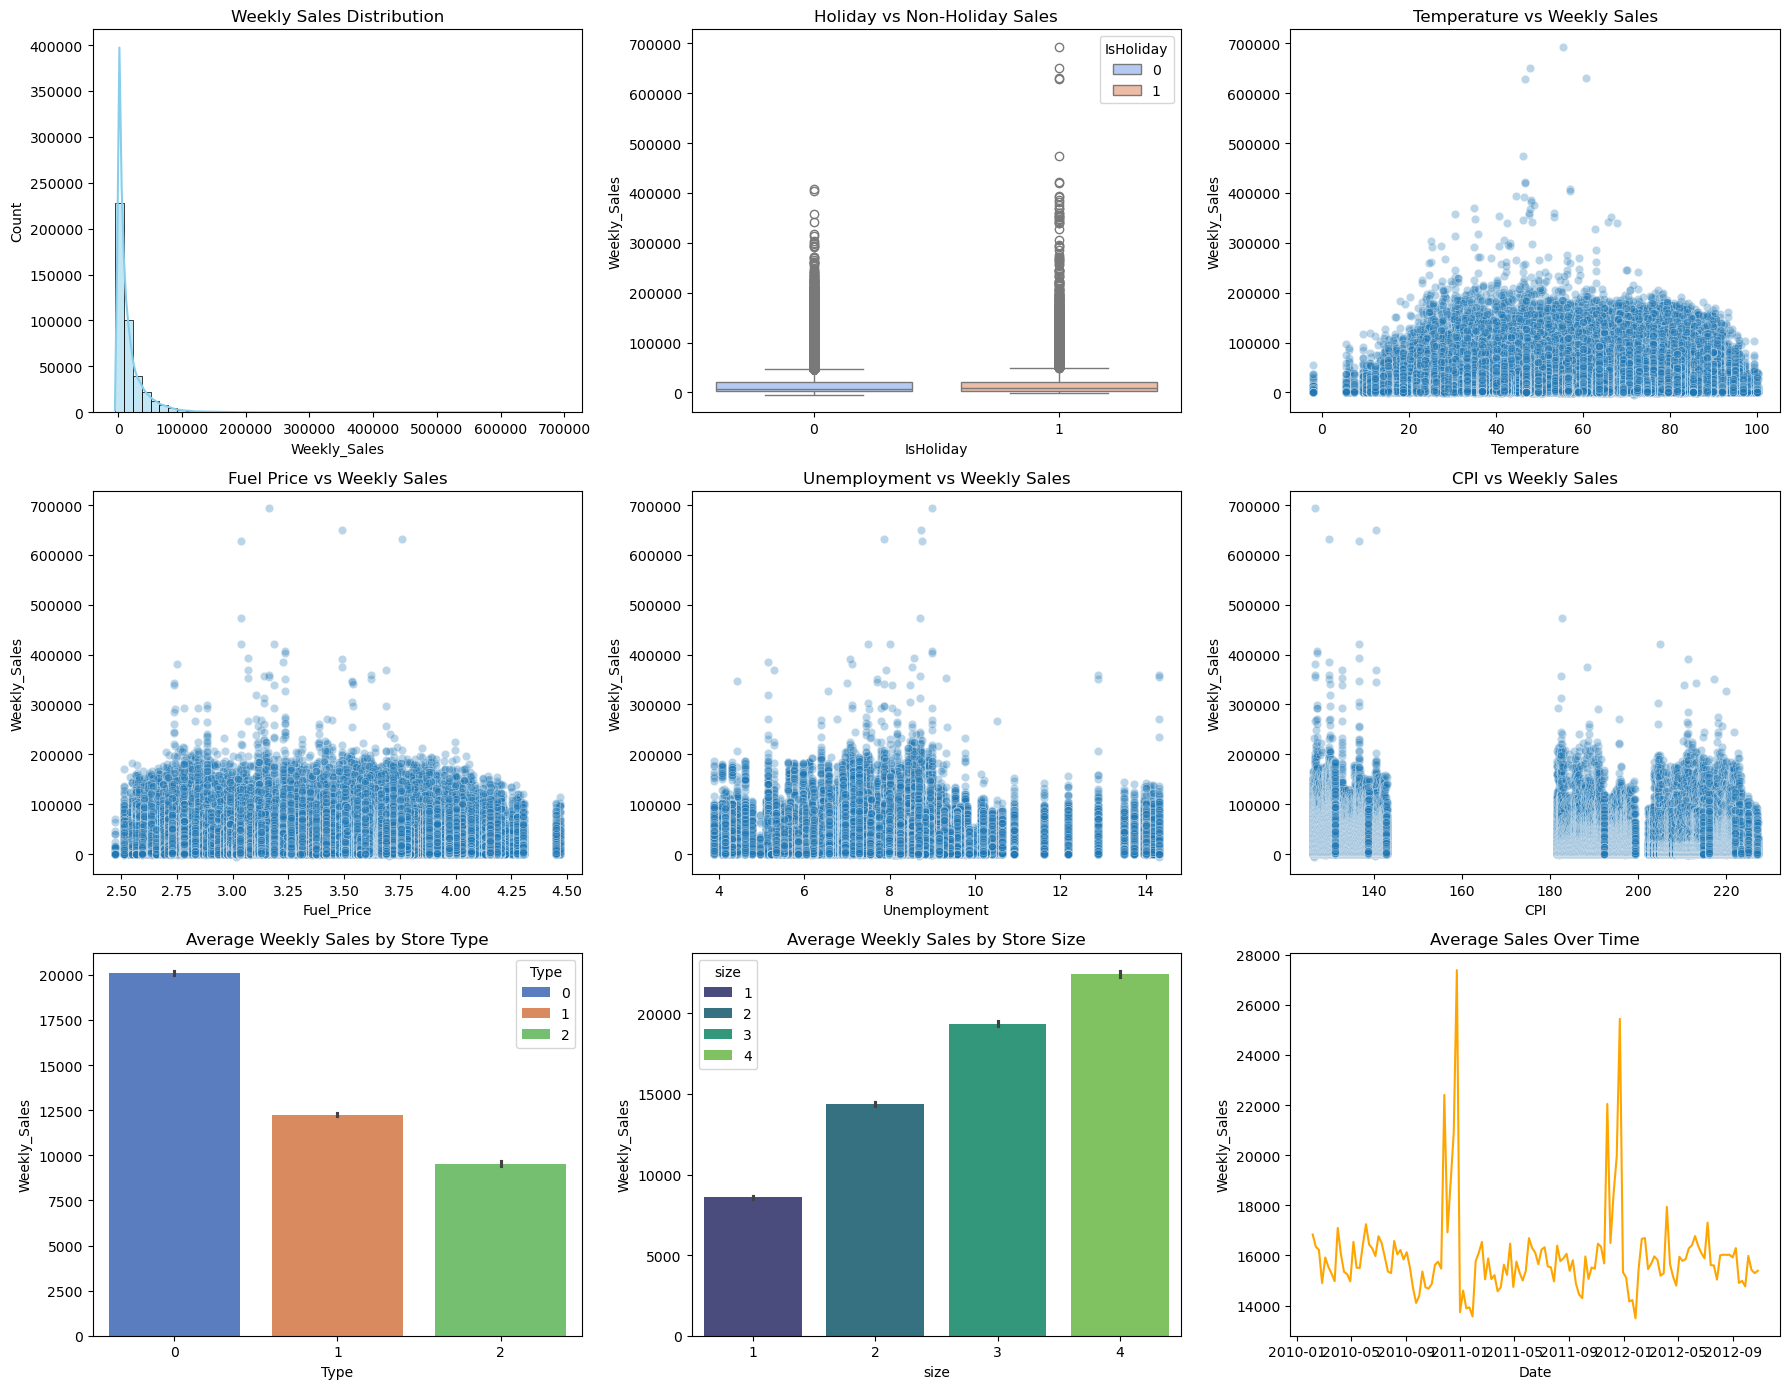

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# Dashboard with multiple plots
fig, axes = plt.subplots(3,3, figsize=(18,14))

# 1. Weekly Sales Distribution
sns.histplot(df['Weekly_Sales'], bins=50, kde=True, color="skyblue", ax=axes[0,0])
axes[0,0].set_title("Weekly Sales Distribution")

# 2. Holiday vs Non-Holiday
sns.boxplot(x='IsHoliday', y='Weekly_Sales', data=df, palette="coolwarm",hue='IsHoliday', ax=axes[0,1])
axes[0,1].set_title("Holiday vs Non-Holiday Sales")

# 3. Temperature vs Sales
sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df, alpha=0.3, ax=axes[0,2])
axes[0,2].set_title("Temperature vs Weekly Sales")

# 4. Fuel Price vs Sales
sns.scatterplot(x='Fuel_Price', y='Weekly_Sales', data=df, alpha=0.3, ax=axes[1,0])
axes[1,0].set_title("Fuel Price vs Weekly Sales")

# 5. Unemployment vs Sales
sns.scatterplot(x='Unemployment', y='Weekly_Sales', data=df, alpha=0.3, ax=axes[1,1])
axes[1,1].set_title("Unemployment vs Weekly Sales")

# 6. CPI vs Sales
sns.scatterplot(x='CPI', y='Weekly_Sales', data=df, alpha=0.3, ax=axes[1,2])
axes[1,2].set_title("CPI vs Weekly Sales")

# 7. Store Type
sns.barplot(x='Type', y='Weekly_Sales', data=df, estimator=np.mean, palette="muted",hue='Type', ax=axes[2,0])
axes[2,0].set_title("Average Weekly Sales by Store Type")

# 8. Store Size (Binned)
sns.barplot(x='size', y='Weekly_Sales', data=df, estimator=np.mean, palette="viridis",hue='size', ax=axes[2,1])
axes[2,1].set_title("Average Weekly Sales by Store Size")

# 9. Sales Trend over Time
df['Date'] = pd.to_datetime(df['Date'])
weekly_trend = df.groupby('Date')['Weekly_Sales'].mean().reset_index()
sns.lineplot(x='Date', y='Weekly_Sales', data=weekly_trend, ax=axes[2,2], color="orange")
axes[2,2].set_title("Average Sales Over Time")

plt.tight_layout()
plt.show()


In [20]:
df['Type'] = df['Type'].astype('category').cat.codes
df['size'] = df['size'].astype('category').cat.codes

# 2. Train: Convert Date column to datetime format

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week



In [21]:
print(df.head())

        Store  Dept       Date  Weekly_Sales  IsHoliday  Temperature  \
0           1     1 2010-02-05      24924.50          0        42.31   
277665     29     5 2010-02-05      15552.08          0        24.36   
277808     29     6 2010-02-05       3200.22          0        24.36   
277951     29     7 2010-02-05      10820.05          0        24.36   
278094     29     8 2010-02-05      20055.64          0        24.36   

        Fuel_Price  MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5  \
0            2.572        0.0        0.0        0.0        0.0        0.0   
277665       2.788        0.0        0.0        0.0        0.0        0.0   
277808       2.788        0.0        0.0        0.0        0.0        0.0   
277951       2.788        0.0        0.0        0.0        0.0        0.0   
278094       2.788        0.0        0.0        0.0        0.0        0.0   

               CPI  Unemployment  Type  size  Year  Month  Week  
0       211.096358         8.106     0

In [22]:
df = df.drop(['Date',], axis=1)

In [23]:
#df = df.drop(['Temperature','Fuel_Price','MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5','CPI','Unemployment'], axis=1) 

In [29]:
print(df.head())

        Store  Dept  Weekly_Sales  IsHoliday  Temperature  Fuel_Price  \
0           1     1      24924.50          0        42.31       2.572   
277665     29     5      15552.08          0        24.36       2.788   
277808     29     6       3200.22          0        24.36       2.788   
277951     29     7      10820.05          0        24.36       2.788   
278094     29     8      20055.64          0        24.36       2.788   

        MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  \
0             0.0        0.0        0.0        0.0        0.0  211.096358   
277665        0.0        0.0        0.0        0.0        0.0  131.527903   
277808        0.0        0.0        0.0        0.0        0.0  131.527903   
277951        0.0        0.0        0.0        0.0        0.0  131.527903   
278094        0.0        0.0        0.0        0.0        0.0  131.527903   

        Unemployment  Type  size  Year  Month  Week  
0              8.106     0     2  2010      

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score

X = df.drop('Weekly_Sales', axis=1)
y = df['Weekly_Sales']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)


xgb_model.fit(x_train, y_train)


y_pred = xgb_model.predict(x_test)


rmse = np.sqrt(root_mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"XGBoost RMSE: {rmse:.2f}")
print(f"XGBoost R² score: {r2:.4f}")




XGBoost RMSE: 72.06
XGBoost R² score: 0.9481


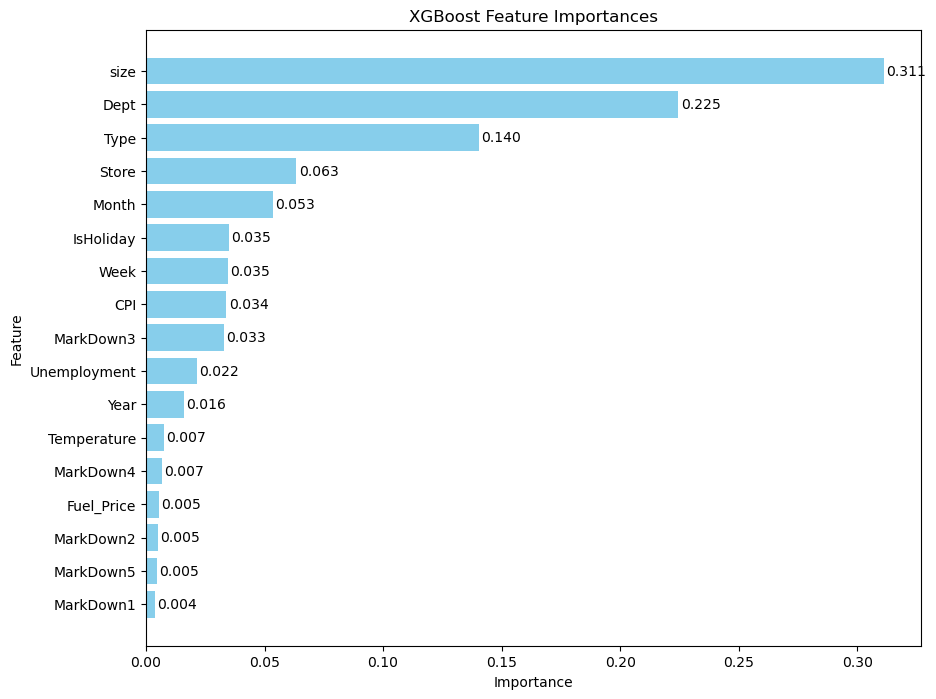

In [32]:
from xgboost import plot_importance


importance = xgb_model.feature_importances_


feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})


feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)


plt.figure(figsize=(10, 8))
bars = plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')


for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.001, bar.get_y() + bar.get_height()/2, f'{width:.3f}', va='center')

plt.title("XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [33]:
test_=pd.read_csv("test.csv")
test_data=pd.merge(test_,features,on=['Store','Date','IsHoliday'])
test_data=pd.merge(test_data,stores,on='Store')

print(test_data.head())

   Store  Dept        Date  IsHoliday  Temperature  Fuel_Price  MarkDown1  \
0      1     1  2012-11-02      False        55.32       3.386    6766.44   
1      1     1  2012-11-09      False        61.24       3.314   11421.32   
2      1     1  2012-11-16      False        52.92       3.252    9696.28   
3      1     1  2012-11-23       True        56.23       3.211     883.59   
4      1     1  2012-11-30      False        52.34       3.207    2460.03   

   MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment Type  \
0    5147.70      50.82    3639.90    2737.42  223.462779         6.573    A   
1    3370.89      40.28    4646.79    6154.16  223.481307         6.573    A   
2     292.10     103.78    1133.15    6612.69  223.512911         6.573    A   
3       4.17   74910.32     209.91     303.32  223.561947         6.573    A   
4        NaN    3838.35     150.57    6966.34  223.610984         6.573    A   

     Size  
0  151315  
1  151315  
2  151315  
3  15131

In [34]:
test_data['Date'] = pd.to_datetime(test_data['Date'])
test_data = test_data.sort_values('Date')  # optional: sort by date
test_data[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']] = \
test_data[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].fillna(0)


# 3. Stores: Bin Size into 4 categories and convert to numbers
test_data['size_bin'] = pd.qcut(test_data['Size'], 4, labels=['Small', 'Medium', 'Large', 'XL'])
size_mapping = {'Small': 1, 'Medium': 2, 'Large': 3, 'XL': 4}
test_data['size'] = test_data['size_bin'].map(size_mapping)

# Drop old columns if not needed
test_data = test_data.drop(['Size', 'size_bin'], axis=1)

test_data['Type'] = test_data['Type'].astype('category').cat.codes

test_data['IsHoliday'] =test_data['IsHoliday'].astype(int)

test_data['Date'] = pd.to_datetime(test_data['Date'])

test_data['Type'] = test_data['Type'].astype('category').cat.codes
test_data['size'] = test_data['size'].astype('category').cat.codes
test_data['Year'] = test_data['Date'].dt.year
test_data['Month'] = test_data['Date'].dt.month
test_data['Week'] = test_data['Date'].dt.isocalendar().week
print(test_data.head())


       Store  Dept       Date  IsHoliday  Temperature  Fuel_Price  MarkDown1  \
0          1     1 2012-11-02          0        55.32       3.386    6766.44   
48640     19    10 2012-11-02          0        46.81       3.970   11686.96   
42002     16    55 2012-11-02          0        38.20       3.604    2826.02   
57105     22    18 2012-11-02          0        54.55       3.817    8793.36   
65138     25    16 2012-11-02          0        40.83       3.787   12435.08   

       MarkDown2  MarkDown3  MarkDown4  MarkDown5         CPI  Unemployment  \
0        5147.70      50.82    3639.90    2737.42  223.462779         6.573   
48640   18053.48      88.94    5484.50    3833.76  138.622710         7.992   
42002     984.41       4.46     274.18    1411.99  199.290867         5.847   
57105   10347.53       5.62    7350.89     801.32  142.661460         7.543   
65138   16493.02      55.19    1165.36    1144.39  216.156711         7.293   

       Type  size  Year  Month  Week  
0    

In [46]:
# Keep a copy of original Date before preprocessing
if "Date" in test_data.columns:
    test_data["Date_original"] = pd.to_datetime(test_data["Date"])
    test_data = test_data.drop("Date", axis=1)

# Ensure IsHoliday is numeric for model
if test_data["IsHoliday"].dtype == "bool" or test_data["IsHoliday"].dtype == "object":
    test_data["IsHoliday"] = test_data["IsHoliday"].astype(int)

# Make sure test_data has all features
for col in X.columns:
    if col not in test_data.columns:
        test_data[col] = 0

# Reorder to match training features
Final_test = test_data[X.columns]

# Predict
test_data["Predicted_Weekly_Sales"] = xgb_model.predict(Final_test)

# Convert IsHoliday back to bool for readability
test_data["IsHoliday_bool"] = test_data["IsHoliday"].astype(bool)

# Final output
final_output = test_data[["Store", "Dept", "Date_original", "IsHoliday_bool", "Predicted_Weekly_Sales"]]

final_output.head()


,Store,Dept,Date_original,IsHoliday_bool,Predicted_Weekly_Sales
0,1,1,2012-11-02,False,34704.386719
48640,19,10,2012-11-02,False,27748.548828
42002,16,55,2012-11-02,False,7470.907715
57105,22,18,2012-11-02,False,16543.128906
65138,25,16,2012-11-02,False,2074.165283


In [50]:
test_data[['Store', 'Dept', 'Date_original', 'IsHoliday_bool', 'Predicted_Weekly_Sales']].head()

,Store,Dept,Date_original,IsHoliday_bool,Predicted_Weekly_Sales
0,1,1,2012-11-02,False,34704.386719
48640,19,10,2012-11-02,False,27748.548828
42002,16,55,2012-11-02,False,7470.907715
57105,22,18,2012-11-02,False,16543.128906
65138,25,16,2012-11-02,False,2074.165283


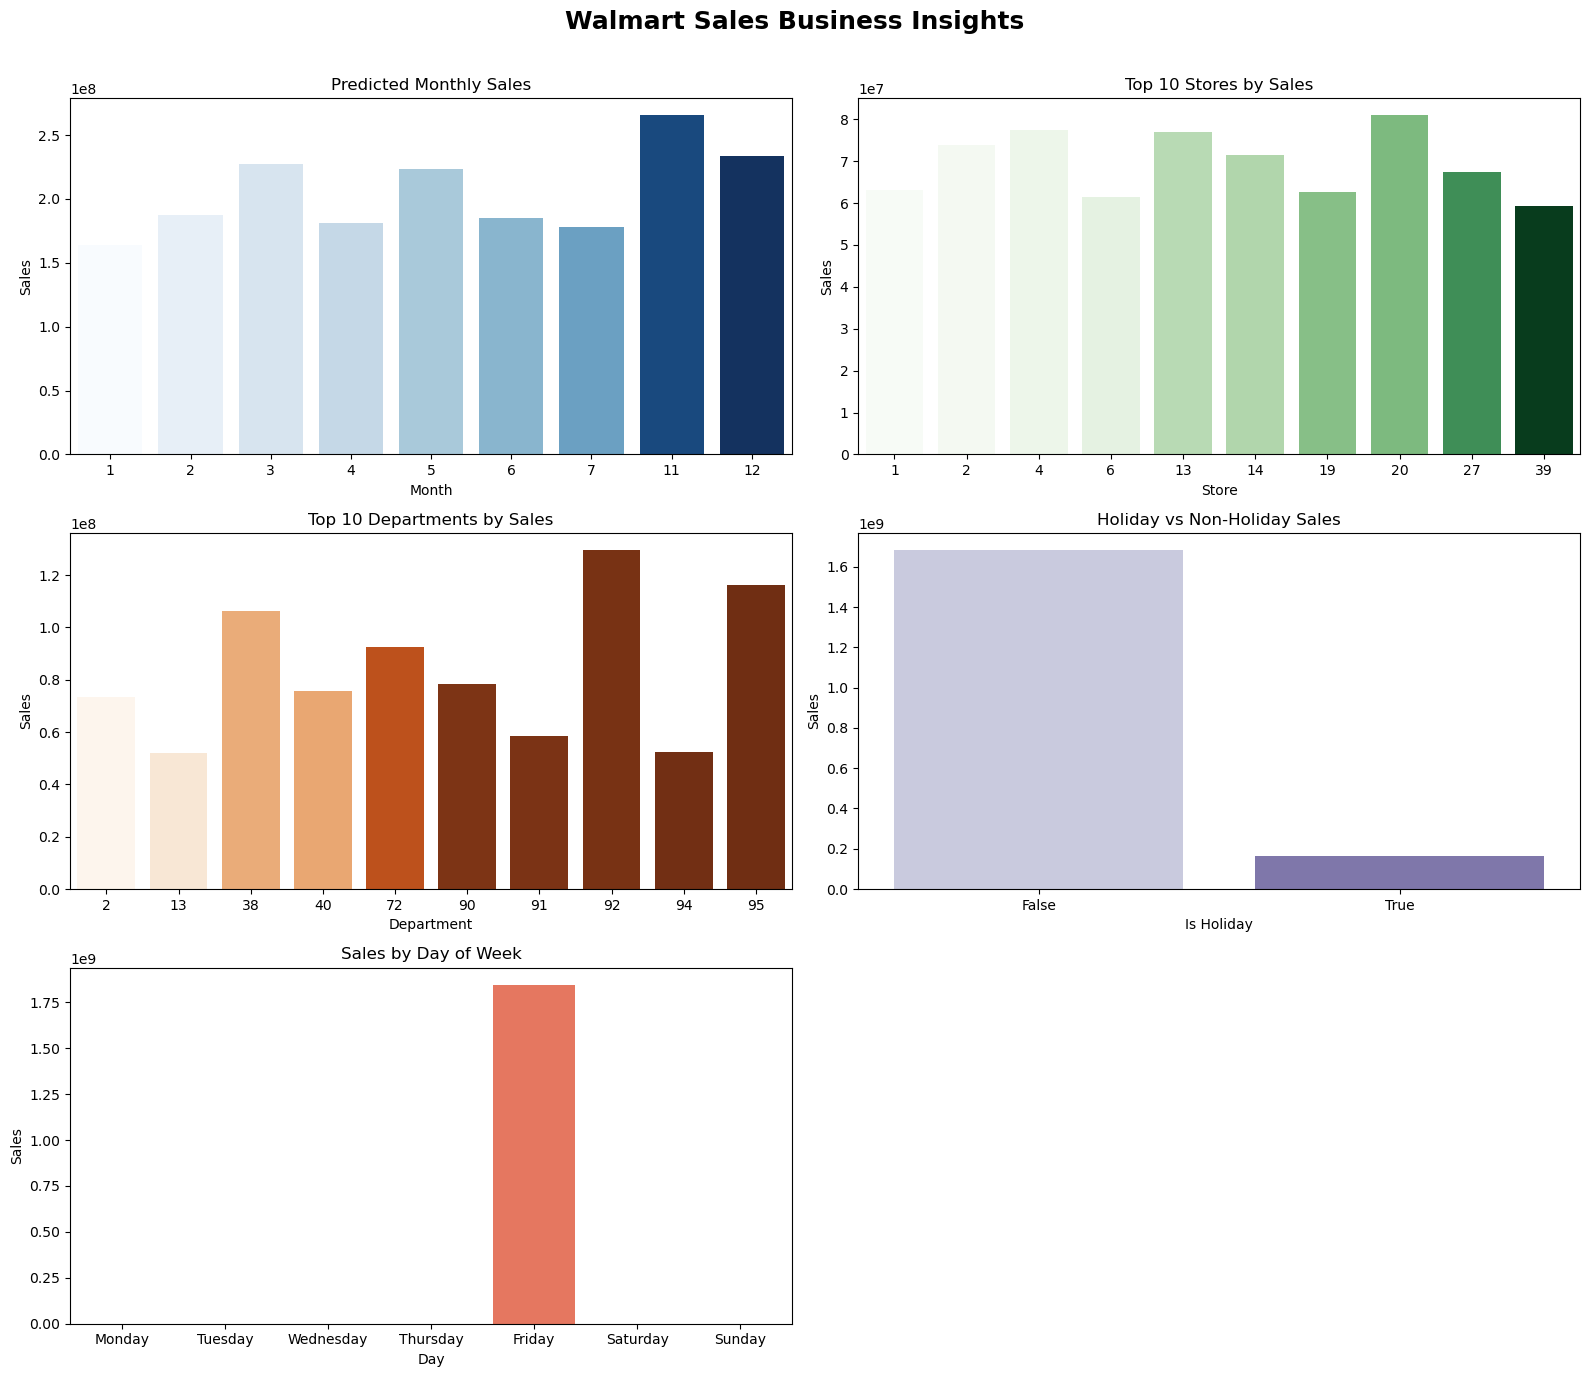

In [52]:

test_data['Date_original'] = pd.to_datetime(test_data['Date_original'])

# --- Aggregations ---
monthly_sales = test_data.groupby(test_data['Date_original'].dt.month)['Predicted_Weekly_Sales'].sum()
store_sales = test_data.groupby('Store')['Predicted_Weekly_Sales'].sum().sort_values(ascending=False).head(10)  # top 10 stores
dept_sales = test_data.groupby('Dept')['Predicted_Weekly_Sales'].sum().sort_values(ascending=False).head(10)   # top 10 depts
holiday_sales = test_data.groupby('IsHoliday_bool')['Predicted_Weekly_Sales'].sum()
weekday_sales = test_data.groupby(test_data['Date_original'].dt.day_name())['Predicted_Weekly_Sales'].sum()

# --- Plot ---
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle("Walmart Sales Business Insights", fontsize=18, fontweight="bold")

# 1. Monthly Sales
sns.barplot(x=monthly_sales.index, y=monthly_sales.values, ax=axes[0,0], palette="Blues",hue=monthly_sales.index,legend=False)
axes[0,0].set_title("Predicted Monthly Sales")
axes[0,0].set_xlabel("Month")
axes[0,0].set_ylabel("Sales")

# 2. Top 10 Stores
sns.barplot(x=store_sales.index, y=store_sales.values, ax=axes[0,1], palette="Greens",hue=store_sales.index,legend=False)
axes[0,1].set_title("Top 10 Stores by Sales")
axes[0,1].set_xlabel("Store")
axes[0,1].set_ylabel("Sales")

# 3. Top 10 Departments
sns.barplot(x=dept_sales.index, y=dept_sales.values, ax=axes[1,0], palette="Oranges",hue=dept_sales.index,legend=False)
axes[1,0].set_title("Top 10 Departments by Sales")
axes[1,0].set_xlabel("Department")
axes[1,0].set_ylabel("Sales")

# 4. Holiday vs Non-Holiday
sns.barplot(x=holiday_sales.index, y=holiday_sales.values, ax=axes[1,1], palette="Purples",hue=holiday_sales.index,legend=False)
axes[1,1].set_title("Holiday vs Non-Holiday Sales")
axes[1,1].set_xlabel("Is Holiday")
axes[1,1].set_ylabel("Sales")

# 5. Weekday Sales
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
sns.barplot(x=weekday_sales.index, y=weekday_sales.values, order=order, ax=axes[2,0], palette="Reds",hue=weekday_sales.index,legend=False)
axes[2,0].set_title("Sales by Day of Week")
axes[2,0].set_xlabel("Day")
axes[2,0].set_ylabel("Sales")

# Remove empty subplot (bottom-right)
fig.delaxes(axes[2,1])

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()



In [56]:
test_data[['Store', 'Dept', 'Date_original', 'IsHoliday_bool', 'Predicted_Weekly_Sales']] \
    .to_csv("walmart_predictions.csv", index=False)
